In [2]:
import pandas as pd
from matplotlib import pyplot as plt 
from matplotlib.gridspec import GridSpec
from matplotlib.transforms import Bbox

import seaborn as sns 
import glob
import numpy as np

import io
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import colormaps
from matplotlib.colors import ListedColormap, BoundaryNorm
# import analysis_utils

In [2]:
AA_dict = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
     'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
     'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
     'ALA': 'A', 'VAL':'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}

# Data preparation

In [3]:
# read in chs tables 
chs_mane_signalp = pd.read_table('results/chs_mane_signalp_241024.tsv', sep='\t')
all_chs_iso = pd.read_table('results/all_chs3_isoforms_with_MANE_select_annotation_241024.tsv',sep='\t')

# format the mane_status column 
chs_mane_signalp.MANE_status.replace('MANE Select', 'mane', inplace=True)
chs_mane_signalp.MANE_status.replace('MANE Plus Clinical', 'mane', inplace=True)
chs_mane_signalp.MANE_status.fillna('isoform', inplace=True)

# prepare parsed column names for read-in structural tables
pos_cols = ['pos_'+str(x) for x in range(1,101)]
struct_colnames = ['CHESS_ID'] 
struct_colnames.extend(pos_cols)

path_to_parsed_structural_tabs = 'results/lddt_sasa_ss2_seq_processing/parsed_full_chs_lddt_sasa_ss2_seq_tables/'
path_to_unparsed_structural_tab = "results/lddt_sasa_ss2_seq_processing/pre_parsing_full_chs_lddt_sasa_ss2_seq_tables/"

# # read in structural data tables 
# lddt_tab = pd.read_table('../final_tables/residue_lddt_table.tsv',sep='\t', names = struct_colnames, skiprows=1)
# sasa_tab = pd.read_table('../final_tables/residue_sasa_table.tsv',sep='\t',  names = struct_colnames, skiprows=1)
# ss_tab = pd.read_table(path_to_unparsed_structural_tab+'residue_ss_table.tsv',sep='\t',  names = struct_colnames, skiprows=1)
# seq_tab = pd.read_table('../final_tables/residue_name_table.tsv',sep='\t',  names = struct_colnames, skiprows=1)

# seq_tab.replace(AA_dict, inplace=True)

# # modify secondary structure table to numeric instead of string values 
# # ss_tab.replace({'H':1, 'E':2, 'C':3}, inplace=True)

# # fill missing values (na) with a uniform '-1'
# lddt_tab.fillna(-1, inplace=True)
# sasa_tab.fillna(-1, inplace=True)
# ss_tab.fillna(-1, inplace=True)

# # drop duplicates that may have been added due to batch-processing of the tables 
# lddt_tab.drop_duplicates(inplace=True)
# sasa_tab.drop_duplicates(inplace=True)
# ss_tab.drop_duplicates(inplace=True)
# seq_tab.drop_duplicates(inplace=True)

# # save out parsed tables of lddt, sasa, ss2, and seq 
# tab_name_prefix = path_to_parsed_structural_tabs
# # for tab_name in ['lddt','sasa','ss','seq']:
# for tab_name in ['ss']:    
#     i_tab = eval(tab_name+'_tab')
#     tab_path = tab_name_prefix+'_'+tab_name+'_structural_tab.tsv'
#     i_tab.to_csv(tab_path, sep='\t',index=False)

# # read in tables of lddt, sasa, ss2, and seq
lddt_tab = pd.read_table(path_to_parsed_structural_tabs+'_lddt_structural_tab.tsv',sep='\t')
sasa_tab = pd.read_table(path_to_parsed_structural_tabs+'_sasa_structural_tab.tsv',sep='\t')
ss_tab = pd.read_table(path_to_parsed_structural_tabs+'_ss_structural_tab.tsv',sep='\t')
seq_tab = pd.read_table(path_to_parsed_structural_tabs+'_seq_structural_tab.tsv',sep='\t')


/tmp/ipykernel_791790/4125204297.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  chs_mane_signalp.MANE_status.replace('MANE Select', 'mane', inplace=True)
/tmp/ipykernel_791790/4125204297.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].metho

In [3]:
# sanity check - no chs ids are missing, and none are added: 
table_lst = [chs_mane_signalp, all_chs_iso, lddt_tab, sasa_tab, ss_tab, seq_tab]
for tab_i in table_lst:
    print(len(tab_i))
    print(len(tab_i.CHESS_ID.unique()))
    print(len(tab_i.drop_duplicates()))

237275
237275
237275
237275
237275
237275
237275
237275
237275
237275
237275
237275
237275
237275
237275
237275
237275
237275


In [5]:
# sanity check - values of individual tables are identical to values in aggregated tables 
chs_id = 'CHS.25427.1'
test = pd.read_table('../results/lddt_sasa_ss2_seq_processing/batch_by_residue_output/'+chs_id+'_sasa_lddt_ss.tsv', sep='\t')

vec1 = test.residue_ss.values[0:100]
vec2 = ss_tab.query('CHESS_ID == @chs_id').loc[:, lddt_tab.columns != 'CHESS_ID'].values 
vec1 == vec2


array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True]])

In [5]:
# prepare subsets by mane /isoform and by sp / no sp prediction of signalp

sp_pred_ids = chs_mane_signalp.query('Prediction == "SP"').CHESS_ID
no_sp_pred_ids = chs_mane_signalp.query('Prediction != "SP"').CHESS_ID

# also take possible SP cases - confidence between 0.5 and 0.9
# note that they are a subset of no_sp_pred_ids 
possible_sp_pred_ids = chs_mane_signalp.query('OTHER > 0.5 and OTHER < 0.9').CHESS_ID

confident_no_sp_pred_ids = no_sp_pred_ids[~no_sp_pred_ids.isin(possible_sp_pred_ids)]

# merge the id vectors 
inclusive_sp_pred_ids = pd.concat([sp_pred_ids, possible_sp_pred_ids])

mane_ids = chs_mane_signalp.query('MANE_status == "mane"').CHESS_ID
isoform_ids = chs_mane_signalp.query('MANE_status != "mane"').CHESS_ID

In [6]:
# prepare lddt and sasa tables filtered by sp chs ids 

sp_lddt = lddt_tab[lddt_tab.CHESS_ID.isin(sp_pred_ids)]
sp_sasa = sasa_tab[sasa_tab.CHESS_ID.isin(sp_pred_ids)]
sp_ss = ss_tab[ss_tab.CHESS_ID.isin(sp_pred_ids)]


# set chs ids to be index for easier filters
sp_lddt.set_index('CHESS_ID', inplace=True)
sp_sasa.set_index('CHESS_ID', inplace=True)
sp_ss.set_index('CHESS_ID', inplace=True)

sp_general_tab = chs_mane_signalp[chs_mane_signalp.CHESS_ID.isin(sp_pred_ids)]


In [7]:
# same, but for possible_sps:
# prepare lddt and sasa tables filtered by sp chs ids 

possible_sp_lddt = lddt_tab[lddt_tab.CHESS_ID.isin(possible_sp_pred_ids)]
possible_sp_sasa = sasa_tab[sasa_tab.CHESS_ID.isin(possible_sp_pred_ids)]
possible_sp_ss = ss_tab[ss_tab.CHESS_ID.isin(possible_sp_pred_ids)]

# set chs ids to be index for easier filters
possible_sp_lddt.set_index('CHESS_ID', inplace=True)
possible_sp_sasa.set_index('CHESS_ID', inplace=True)
possible_sp_ss.set_index('CHESS_ID', inplace=True)

possible_sp_general_tab = chs_mane_signalp[chs_mane_signalp.CHESS_ID.isin(possible_sp_pred_ids)]
possible_sp_general_tab.set_index('CHESS_ID', inplace=True)


# CS cleavage 

In [9]:
# parse the signalP cleavage site columns into position and probability columns 
def parse_cs_position(CS_Pos):
    x = CS_Pos.split('. Pr: ')
    prob = float(x[1])
    cs_pos = x[0].split('CS pos: ')[1].split('-')[0]    
    return cs_pos, prob

# perform on the sp_general tab, no need to perform on possible_sp_tab since they are not annotated for SP (and cleavage)
sp_general_tab.CS_Position.apply(lambda x: parse_cs_position(x))
cs_series = sp_general_tab.CS_Position.apply(lambda x: parse_cs_position(x))
sp_general_tab[['CS_pos','CS_prob']] = pd.DataFrame(cs_series.tolist(), index=sp_general_tab.index)

sp_general_tab.set_index('CHESS_ID', inplace=True)
sp_general_tab

/tmp/ipykernel_1205305/2334343741.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sp_general_tab[['CS_pos','CS_prob']] = pd.DataFrame(cs_series.tolist(), index=sp_general_tab.index)
/tmp/ipykernel_1205305/2334343741.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sp_general_tab[['CS_pos','CS_prob']] = pd.DataFrame(cs_series.tolist(), index=sp_general_tab.index)


,Prediction,OTHER,SP(Sec/SPI),CS_Position,GENE,MANE_status,CS_pos,CS_prob
CHESS_ID,,,,,,,,
CHS.25420.35,SP,0.000207,0.999815,CS pos: 29-30. Pr: 0.9798,PTPRS,mane,29,0.9798
CHS.25420.alt104,SP,0.000290,0.999719,CS pos: 21-22. Pr: 0.9818,PTPRS,isoform,21,0.9818
CHS.25420.alt105,SP,0.000207,0.999815,CS pos: 29-30. Pr: 0.9798,PTPRS,isoform,29,0.9798
CHS.25437.4,SP,0.000400,0.999591,CS pos: 20-21. Pr: 0.9264,CATSPERD,isoform,20,0.9264
CHS.25437.6,SP,0.000400,0.999596,CS pos: 20-21. Pr: 0.9264,CATSPERD,isoform,20,0.9264
...,...,...,...,...,...,...,...,...
CHS.37023.alt112,SP,0.000164,0.999846,CS pos: 30-31. Pr: 0.9336,VIPR1,isoform,30,0.9336
CHS.37023.alt114,SP,0.000164,0.999846,CS pos: 30-31. Pr: 0.9336,VIPR1,isoform,30,0.9336
CHS.37023.15,SP,0.000164,0.999846,CS pos: 30-31. Pr: 0.9336,VIPR1,mane,30,0.9336


In [10]:
# merge the sp and possible_sp tables
inclusive_sp_lddt = pd.concat([sp_lddt, possible_sp_lddt])
inclusive_sp_sasa = pd.concat([sp_sasa, possible_sp_sasa])
inclusive_sp_ss = pd.concat([sp_ss, possible_sp_ss])

inclusive_sp_general_tab = pd.concat([sp_general_tab, possible_sp_general_tab])
inclusive_sp_general_tab.CS_Position.fillna(-1, inplace=True)

/tmp/ipykernel_26911/4047658502.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  inclusive_sp_general_tab.CS_Position.fillna(-1, inplace=True)


# SP structural role - folding \ compensation?

In [4]:
def compute_averages(score_tab, general_tab, id=None, vec_size=100, alt_end_pos=23):
    """
    Compute averages for different sections of the given score vector
    
    Parameters:
    score_vec (array-like): Vector of scores, defaults to None
    end_pos (int): Position to split the vector
    id: Identifier for the row
    vec_size (int): Expected size of score_vec, defaults to 100
    
    Returns:
    dict: Dictionary containing id, averages and end_pos
    """
    
    score_vec = score_tab.query('index == @id').values[0]
    end_pos = general_tab.query('index == @id').CS_pos.values[0]
    end_pos = int(end_pos)
    
    # Input validation
    if score_vec is None or id is None:
        return None
    if end_pos ==-1:
        end_pos = alt_end_pos
    # Ensure score_vec is of correct length
    if len(score_vec) != vec_size:
        return None
    
    # Compute averages
    nterm_avg = np.mean(score_vec[:end_pos+1])
    post_nterm_avg = np.mean(score_vec[end_pos+1:])
    
    # Return results as a dictionary
    return {
        'id': id,
        'nterm_avg': nterm_avg,
        'post_nterm_avg': post_nterm_avg,
        'end_pos': end_pos
    }


In [13]:
# # Compute the SP_region vs following region sasa and lddt averages and merge tables 

# lddt_avg_list = [compute_averages(inclusive_sp_lddt, inclusive_sp_general_tab, x) for x in inclusive_sp_pred_ids]
# lddt_avg_tab = pd.DataFrame(list(lddt_avg_list))

# sasa_avg_list = [compute_averages(inclusive_sp_sasa, inclusive_sp_general_tab, x) for x in inclusive_sp_pred_ids]
# sasa_avg_tab = pd.DataFrame(list(sasa_avg_list))

# sasa_avg_tab.set_index('id', inplace=True)
# lddt_avg_tab.set_index('id', inplace=True)

# sasa_avg_tab.columns = sasa_avg_tab.columns.str.replace('nterm_avg','nterm_avg_sasa')
# lddt_avg_tab.columns = lddt_avg_tab.columns.str.replace('nterm_avg','nterm_avg_lddt')

# sasa_avg_tab.to_csv('sasa_avg_sp_nterm_cterm_by_signalp_cs_pred.tsv',sep='\t', index=False)
# lddt_avg_tab.to_csv('lddt_avg_sp_nterm_cterm_by_signalp_cs_pred.tsv',sep='\t', index=False)

# sasa_avg_tab = pd.read_table('sasa_avg_sp_nterm_cterm_by_signalp_cs_pred.tsv',sep='\t')
# lddt_avg_tab = pd.read_table('lddt_avg_sp_nterm_cterm_by_signalp_cs_pred.tsv',sep='\t')

# problem here with saved table - its not inclusive, but only confident
# check this! merged table seems fine; so probably fine to use just it 

In [4]:
# # merge the sasa \ lddt tables, and save out \ read in 
# lddt_avg_tab_for_merge = lddt_avg_tab[['nterm_avg_lddt', 'post_nterm_avg_lddt']]
# sasa_lddt_avg_tab = sasa_avg_tab.merge(lddt_avg_tab_for_merge, left_index=True, right_index=True)
# sasa_lddt_avg_tab.to_csv('merged_sp_inclusive_sasa_lddt_avg_nterm_post_nterm_by_signalp_cs_pred.tsv',sep='\t',index=True)

sasa_lddt_avg_tab = pd.read_table('../results/merged_sp_inclusive_sasa_lddt_avg_nterm_post_nterm_by_signalp_cs_pred.tsv',sep='\t')
sasa_lddt_avg_tab.set_index('id',inplace=True)

In [5]:
sasa_lddt_avg_tab

,nterm_avg_sasa,post_nterm_avg_sasa,end_pos,nterm_avg_lddt,post_nterm_avg_lddt
id,,,,,
CHS.25420.35,126.245333,57.697429,29,35.069000,85.942571
CHS.25420.alt104,120.244545,61.572179,21,54.816818,91.216538
CHS.25420.alt105,112.561000,86.190429,29,49.956000,63.331143
CHS.25437.4,123.283333,57.498987,20,47.645238,85.932658
CHS.25437.6,126.810476,56.811139,20,45.040000,85.556962
...,...,...,...,...,...
CHS.37017.alt139,145.811667,120.170132,23,28.975833,56.499342
CHS.37017.alt140,141.297500,117.590789,23,28.685833,57.261316
CHS.37017.alt141,141.297500,117.590789,23,28.685833,57.261316


In [17]:
# write out the inclusive_sp_general table 
# inclusive_sp_general_tab.to_csv('inclusive_sp_general_tab_120125_struct_role_domain_completion_ipynb.tsv',sep='\t')

Text(0.5, 0, 'nterm_avg_sasa')

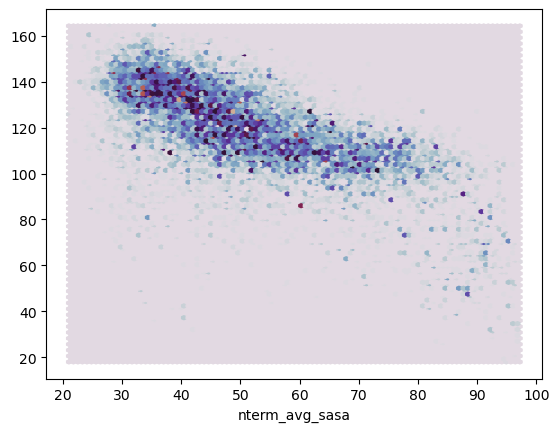

In [38]:
plt.hexbin(sasa_lddt_avg_tab['nterm_avg_lddt'],sasa_lddt_avg_tab['nterm_avg_sasa'], cmap='twilight')
plt.xlabel('nterm_avg_lddt')
plt.xlabel('nterm_avg_sasa')

Text(0.5, 0, 'post_nterm_avg_sasa')

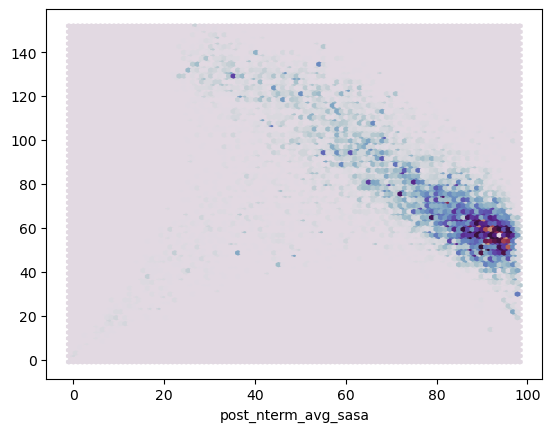

In [39]:
plt.hexbin(sasa_lddt_avg_tab['post_nterm_avg_lddt'],sasa_lddt_avg_tab['post_nterm_avg_sasa'], cmap='twilight')
plt.xlabel('post_nterm_avg_lddt')
plt.xlabel('post_nterm_avg_sasa')

# filter tab by potential for structural role and characterize it 

In [5]:
# define cutoffs for screening structural role candidates 
nterm_sasa_cutoff = 90
structural_role_candidates = sasa_lddt_avg_tab.query('nterm_avg_sasa <= @nterm_sasa_cutoff').index